In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [19]:
import os
import pandas as pd

# Define the base files list
files = [
    "data/CRMLSSold202506.csv", "data/CRMLSSold202507.csv", "data/CRMLSSold202508.csv",
    "data/CRMLSSold202509.csv", "data/CRMLSSold202510.csv", "data/CRMLSSold202511.csv",
    "data/CRMLSSold202512.csv", "data/CRMLSSold202601.csv", "data/CRMLSSold202602.csv",
    "data/CRMLSSold202603.csv", "data/CRMLSSold202604.csv", "data/CRMLSSold202605.csv"
]

# Adjust path if notebook is running inside the 'notebooks' directory
valid_files = []
for f in files:
    if os.path.exists(f):
        valid_files.append(f)
    elif os.path.exists(os.path.join("..", f)):
        valid_files.append(os.path.join("..", f))

# Verify we found the files before combining
if not valid_files:
    raise FileNotFoundError("Could not find the data files. Check that the 'data' folder contains your CSVs.")

# Concatenate all dataframes efficiently
df = pd.concat([pd.read_csv(f, low_memory=False) for f in valid_files], ignore_index=True)
print(f"Combined Dataframe Shape: {df.shape}")

Combined Dataframe Shape: (258669, 78)


In [20]:
# Isolate the target dataset segment based on project parameters
df_restricted = df[
    (df["PropertyType"] == "Residential") & 
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

print(f"Filtered Dataframe Shape: {df_restricted.shape}")

Filtered Dataframe Shape: (130220, 78)


In [21]:
# Analyze quantiles to determine robust boundary cutoffs for visualizations
metrics = ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]
df_restricted[metrics].describe()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
count,1.302200e+05,130152.000000,130220.000000,130208.000000,1.279840e+05
mean,1.345628e+06,2049.656470,3.494962,2.634016,3.888289e+05
std,8.260291e+06,1047.244954,0.963449,1.131053,1.803893e+07
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,6.250000e+05,1387.000000,3.000000,2.000000,5.663000e+03
50%,8.900000e+05,1820.000000,3.000000,2.000000,7.281000e+03
75%,1.415000e+06,2441.000000,4.000000,3.000000,1.045400e+04
max,9.895000e+08,56500.000000,22.000000,35.000000,1.938943e+09


In [22]:
# Apply standard filter bounds to drop extreme outliers and improve visualization readability
df_filtered = df_restricted[
    (df_restricted["ClosePrice"] > 10000) & (df_restricted["ClosePrice"] < 6500000) &
    (df_restricted["LivingArea"] < 10000) & 
    (df_restricted["LotSizeSquareFeet"] < 150000)
].copy()

In [23]:
# Filter and save to a new filtered dataframe
filtered_df = df[
    (df["PropertyType"] == "Residential") & 
    (df["PropertySubType"] == "Single Family Residence")
]

print("Filtered dataset shape:", filtered_df.shape)

Filtered dataset shape: (0, 78)


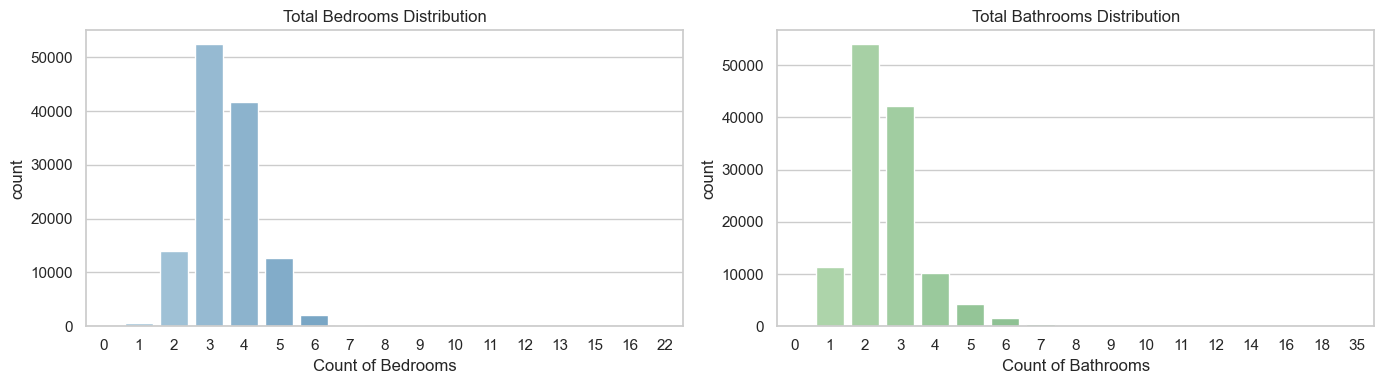

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(
    data=df_filtered, 
    x=df_filtered["BedroomsTotal"].dropna().astype(int), 
    hue=df_filtered["BedroomsTotal"].dropna().astype(int), 
    ax=axes[0], 
    palette="Blues_d", 
    legend=False
)
axes[0].set_title("Total Bedrooms Distribution")
axes[0].set_xlabel("Count of Bedrooms")

sns.countplot(
    data=df_filtered, 
    x=df_filtered["BathroomsTotalInteger"].dropna().astype(int), 
    hue=df_filtered["BathroomsTotalInteger"].dropna().astype(int), 
    ax=axes[1], 
    palette="Greens_d", 
    legend=False
)
axes[1].set_title("Total Bathrooms Distribution")
axes[1].set_xlabel("Count of Bathrooms")

plt.tight_layout()
plt.show()